# Laboratory Work 4

### Load BOWS2 Images
Prepare an image array for tasks from `lab-4.pdf`.

In [68]:
from pathlib import Path

import numpy as np
from PIL import Image

In [69]:
cover_dir = Path('BOWS2') / 'cover'

if not cover_dir.exists():
    raise FileNotFoundError(f'Directory not found: {cover_dir.resolve()}')

image_paths = sorted(cover_dir.glob('*.pgm'), key=lambda p: int(p.stem))
if not image_paths:
    raise RuntimeError(f'No .pgm files found in {cover_dir}')

images = [np.array(Image.open(path), dtype=np.uint8) for path in image_paths]
images = np.stack(images, axis=0)

print(f'Loaded images: {images.shape[0]}')
print(f'Image size: {images.shape[1:]}')
print(f'dtype: {images.dtype}')

Loaded images: 2000
Image size: (256, 256)
dtype: uint8


### Step 1. Feature Vector for the "Pairs of Values" Steganalysis Method
Only `pair_values` is used (variant 11).
Settings: `p = 2`, LSB replacement embedding.
For `p = 2`, each pair is `(v, v xor 2)`, e.g. `(0,2), (1,3), (4,6), (5,7), ...`.
Feature vector size is 256:
- 128 relative imbalances for PoV pairs;
- 128 normalized frequencies of the same pairs.

In [70]:
def pair_value_feature_vector(image: np.ndarray, p: int = 2) -> np.ndarray:
    """Build a PoV feature vector for one grayscale uint8 image and bit-plane p."""
    if not (1 <= p <= 8):
        raise ValueError('p must be in [1, 8] for uint8 images')

    image_u8 = image.astype(np.uint8, copy=False)
    hist = np.bincount(image_u8.ravel(), minlength=256).astype(np.float64)

    mask = 1 << (p - 1)
    left = np.arange(256, dtype=np.uint16)
    right = left ^ mask

    # Keep each unordered pair exactly once.
    pair_selector = left < right
    left = left[pair_selector]
    right = right[pair_selector]

    left_counts = hist[left]
    right_counts = hist[right]
    pair_counts = left_counts + right_counts

    rel_pair_diff = np.divide(
        left_counts - right_counts,
        pair_counts,
        out=np.zeros_like(pair_counts),
        where=pair_counts > 0,
    )

    pair_weight = pair_counts / pair_counts.sum()

    return np.concatenate([rel_pair_diff, pair_weight], axis=0)


def extract_pair_features(images: np.ndarray, p: int = 2) -> np.ndarray:
    """Build a feature matrix with shape [n_images, 256] for PoV method."""
    return np.vstack([pair_value_feature_vector(img, p=p) for img in images])

In [71]:
BIT_PLANE = 2
X_features = extract_pair_features(images, p=BIT_PLANE)

print('Method: pair_values')
print(f'Bit-plane p: {BIT_PLANE}')
print(f'Feature matrix shape: {X_features.shape}')
print(f'Features per image: {X_features.shape[1]}')
print('First 10 features of the first image:')
print(np.round(X_features[0, :10], 6))

Method: pair_values
Bit-plane p: 2
Feature matrix shape: (2000, 256)
Features per image: 256
First 10 features of the first image:
[ 0.        0.        0.       -1.       -0.341772 -0.418803 -0.126984
 -0.28382  -0.243796 -0.17907 ]


### Step 2. Steganographic System Simulation
Simulate LSB replacement for the first `K/2` images by filling a fraction `q` of bit-plane `p` with independent uniform white noise bitstreams. For variant 11 (odd), embedding positions are selected sequentially.

In [72]:
def simulate_lsb_replacement(
    images: np.ndarray,
    p: int,
    q: float,
    K: int | None = None,
    position_mode: str = "sequential",
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Return (images_sim, y) where:
    - images_sim: first K/2 images are modified, second K/2 are unchanged
    - y: labels for the first K images (1 = embedded, 0 = clean)
    """
    if not (1 <= p <= 8):
        raise ValueError("p must be in [1, 8] for uint8 images")
    if not (0.0 <= q <= 1.0):
        raise ValueError("q must be in [0, 1]")
    if position_mode not in {"sequential", "random"}:
        raise ValueError("position_mode must be \"sequential\" or \"random\"")

    n_images, h, w = images.shape
    if K is None:
        K = n_images
    K = int(K)
    if K <= 0 or K > n_images:
        raise ValueError("K must be in [1, number_of_images]")

    half = K // 2
    n_pixels = h * w
    m = int(np.floor(q * n_pixels))

    images_sim = images[:K].copy()
    y = np.zeros(K, dtype=np.uint8)
    y[:half] = 1

    if m == 0 or half == 0:
        return images_sim, y

    mask = np.uint8(1 << (p - 1))
    inv_mask = np.uint8(255 ^ mask)
    rng = np.random.default_rng(seed)

    if position_mode == "sequential":
        idx = np.arange(m, dtype=np.int64)
        noise = rng.integers(0, 2, size=(half, m), dtype=np.uint8)
        for i in range(half):
            flat = images_sim[i].reshape(-1)
            flat[idx] = (flat[idx] & inv_mask) | (noise[i] * mask)
    else:
        for i in range(half):
            idx = rng.choice(n_pixels, size=m, replace=False)
            noise = rng.integers(0, 2, size=m, dtype=np.uint8)
            flat = images_sim[i].reshape(-1)
            flat[idx] = (flat[idx] & inv_mask) | (noise * mask)

    return images_sim, y

In [73]:
BIT_PLANE = 2
POSITION_MODE = "sequential"

# You can change q and K for experiments
Q_FILL = 0.3
K_IMAGES = images.shape[0]

images_sim, y = simulate_lsb_replacement(
    images=images,
    p=BIT_PLANE,
    q=Q_FILL,
    K=K_IMAGES,
    position_mode=POSITION_MODE,
    seed=42,
)

print(f"p = {BIT_PLANE}, q = {Q_FILL}, K = {K_IMAGES}")
print(f"Position mode: {POSITION_MODE}")
print(f"Simulated set shape: {images_sim.shape}")
print(f"Embedded images: {int(y.sum())}, clean images: {int((y == 0).sum())}")
print(f"Pixels modified per embedded image: {int(np.floor(Q_FILL * images.shape[1] * images.shape[2]))}")

p = 2, q = 0.3, K = 2000
Position mode: sequential
Simulated set shape: (2000, 256, 256)
Embedded images: 1000, clean images: 1000
Pixels modified per embedded image: 19660


### Step 3 Prep. Build Pair-Values Features and Create Train/Test Split
Compute PoV features from `images_sim` and split data using the first 70% of each class (embedded and clean) for training, with the remaining 30% for testing.

In [74]:
if 'images_sim' not in globals() or 'y' not in globals():
    raise NameError('Run Step 2 simulation cell first to create `images_sim` and `y`.')

if 'BIT_PLANE' not in globals():
    BIT_PLANE = 2

X_features_sim = extract_pair_features(images_sim, p=BIT_PLANE)

embedded_idx = np.where(y == 1)[0]
clean_idx = np.where(y == 0)[0]

n_train_embedded = int(np.floor(0.7 * len(embedded_idx)))
n_train_clean = int(np.floor(0.7 * len(clean_idx)))

train_idx = np.concatenate([
    embedded_idx[:n_train_embedded],
    clean_idx[:n_train_clean],
])
test_idx = np.concatenate([
    embedded_idx[n_train_embedded:],
    clean_idx[n_train_clean:],
])

X_train = X_features_sim[train_idx]
y_train = y[train_idx]
X_test = X_features_sim[test_idx]
y_test = y[test_idx]

print('Method: pair_values')
print(f'Bit-plane p: {BIT_PLANE}')
print(f'Feature matrix shape: {X_features_sim.shape}')
print(f'Embedded samples: {len(embedded_idx)}, clean samples: {len(clean_idx)}')
print(f'Train size: {len(train_idx)} (embedded={n_train_embedded}, clean={n_train_clean})')
print(f'Test size: {len(test_idx)}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

Method: pair_values
Bit-plane p: 2
Feature matrix shape: (2000, 256)
Embedded samples: 1000, clean samples: 1000
Train size: 1400 (embedded=700, clean=700)
Test size: 600
X_train: (1400, 256), X_test: (600, 256)


### Step 3. Train Classifier and Evaluate Quality
Train a binary classifier on the 70/30 split and report both metrics: Accuracy and F1. Also build the confusion matrix.

Accuracy: 0.505000
F1-score: 0.460980
Confusion matrix (rows=true, cols=pred):
[[176 124]
 [173 127]]


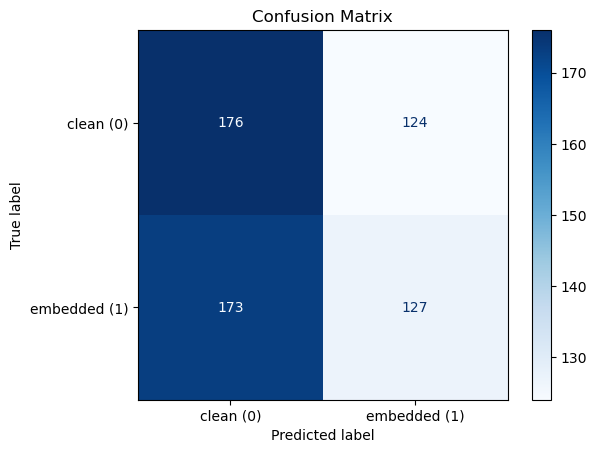

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if not all(name in globals() for name in ['X_train', 'y_train', 'X_test', 'y_test']):
    raise NameError('Run Step 3 prep cell first to create X_train, y_train, X_test, y_test.')

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42)),
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {acc:.6f}')
print(f'F1-score: {f1:.6f}')
print('Confusion matrix (rows=true, cols=pred):')
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['clean (0)', 'embedded (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

### Steps 4-5. Evaluate on Test Set for q = 0.1..1.0
Repeat steps 2-4 for `q` from 0.1 to 1.0 with step 0.1. Store both metrics (`Accuracy`, `F1-score`) and plot metric curves versus `q`.

Method: pair_values, p=2
  q  accuracy  f1_score
0.1  0.480000  0.424354
0.2  0.475000  0.422018
0.3  0.505000  0.460980
0.4  0.548333  0.509946
0.5  0.551667  0.518784
0.6  0.556667  0.514599
0.7  0.620000  0.592857
0.8  0.670000  0.642599
0.9  0.696667  0.670290
1.0  0.821667  0.818336


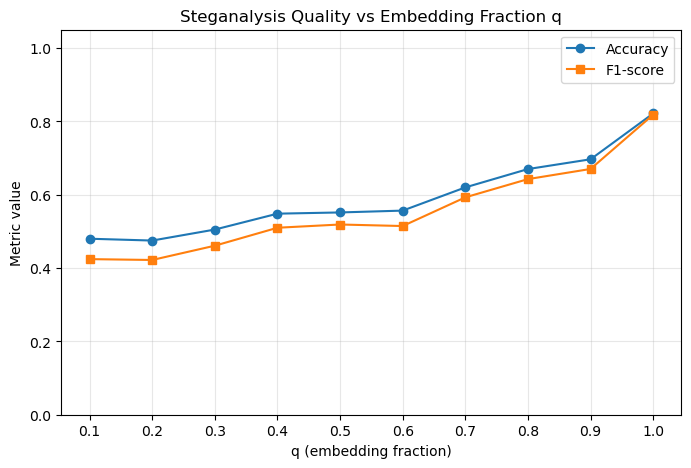

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

required = ['images', 'simulate_lsb_replacement', 'extract_pair_features']
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f'Missing required objects: {missing}. Run previous cells first.')

if 'BIT_PLANE' not in globals():
    BIT_PLANE = 2

POSITION_MODE = 'sequential'  # variant 11 is odd
K_IMAGES = images.shape[0]
Q_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 1)

results = []

for q in Q_VALUES:
    images_sim_q, y_q = simulate_lsb_replacement(
        images=images,
        p=BIT_PLANE,
        q=float(q),
        K=K_IMAGES,
        position_mode=POSITION_MODE,
        seed=42,
    )

    X_q = extract_pair_features(images_sim_q, p=BIT_PLANE)

    embedded_idx = np.where(y_q == 1)[0]
    clean_idx = np.where(y_q == 0)[0]

    n_train_embedded = int(np.floor(0.7 * len(embedded_idx)))
    n_train_clean = int(np.floor(0.7 * len(clean_idx)))

    train_idx = np.concatenate([
        embedded_idx[:n_train_embedded],
        clean_idx[:n_train_clean],
    ])
    test_idx = np.concatenate([
        embedded_idx[n_train_embedded:],
        clean_idx[n_train_clean:],
    ])

    X_train_q = X_q[train_idx]
    y_train_q = y_q[train_idx]
    X_test_q = X_q[test_idx]
    y_test_q = y_q[test_idx]

    clf_q = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=42)),
    ])
    clf_q.fit(X_train_q, y_train_q)
    y_pred_q = clf_q.predict(X_test_q)

    acc_q = accuracy_score(y_test_q, y_pred_q)
    f1_q = f1_score(y_test_q, y_pred_q)

    results.append({
        'q': float(q),
        'accuracy': float(acc_q),
        'f1_score': float(f1_q),
    })

results_df = pd.DataFrame(results).sort_values('q').reset_index(drop=True)
print(f'Method: pair_values, p={BIT_PLANE}')
print(results_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(results_df['q'], results_df['accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['q'], results_df['f1_score'], marker='s', label='F1-score')
plt.xticks(Q_VALUES)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.xlabel('q (embedding fraction)')
plt.ylabel('Metric value')
plt.title('Steganalysis Quality vs Embedding Fraction q')
plt.legend()
plt.show()

                 model   q  accuracy  f1_score  fit_time_sec
  KNeighborsClassifier 0.1  0.528333  0.380744      0.006211
  KNeighborsClassifier 0.2  0.508333  0.365591      0.007104
  KNeighborsClassifier 0.3  0.535000  0.431772      0.004222
  KNeighborsClassifier 0.4  0.531667  0.439122      0.005034
  KNeighborsClassifier 0.5  0.545000  0.473988      0.004550
  KNeighborsClassifier 0.6  0.543333  0.490706      0.003961
  KNeighborsClassifier 0.7  0.588333  0.564374      0.004002
  KNeighborsClassifier 0.8  0.626667  0.621622      0.004687
  KNeighborsClassifier 0.9  0.668333  0.683625      0.004175
  KNeighborsClassifier 1.0  0.766667  0.789790      0.003890
             LinearSVC 0.1  0.476667  0.409774      0.180926
             LinearSVC 0.2  0.488333  0.430427      0.189934
             LinearSVC 0.3  0.531667  0.491863      0.145190
             LinearSVC 0.4  0.551667  0.520499      0.258951
             LinearSVC 0.5  0.556667  0.528369      0.187796
             LinearSVC 0

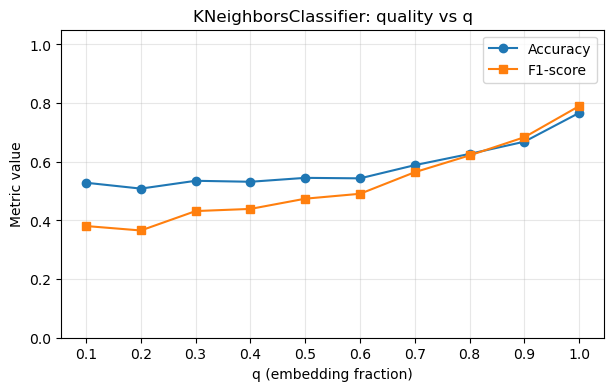

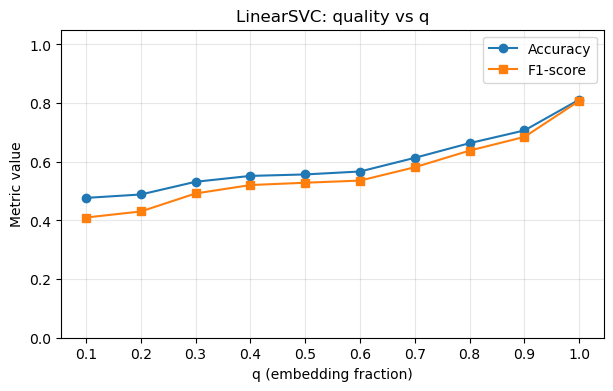

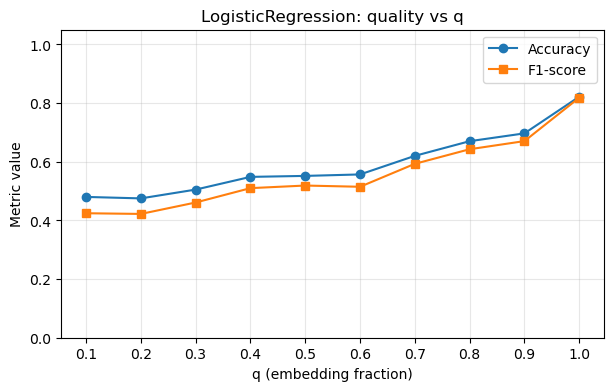

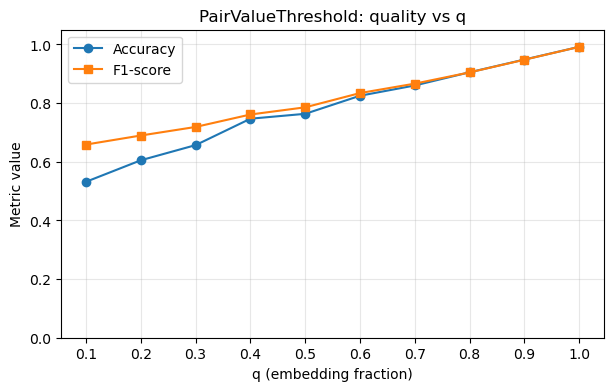

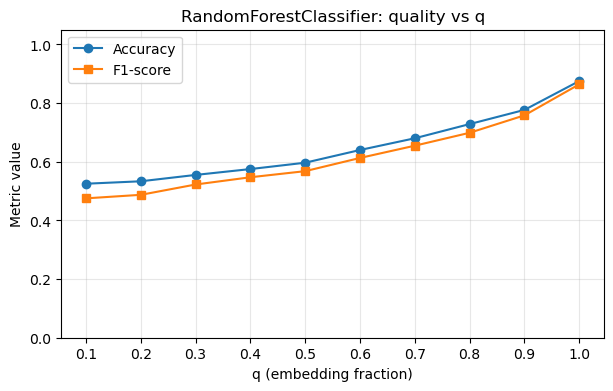

In [77]:
# Comparative study: 5 classifiers on pair_values features across q values
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

required = ['images', 'simulate_lsb_replacement', 'extract_pair_features']
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f'Missing required objects: {missing}. Run previous cells first.')

if 'BIT_PLANE' not in globals():
    BIT_PLANE = 2

POSITION_MODE = 'sequential'  # variant 11 is odd
K_IMAGES = images.shape[0]
Q_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 1)

class PairValueThresholdClassifier(BaseEstimator, ClassifierMixin):
    """Rule-based baseline on pair_values features."""
    def __init__(self):
        self.threshold_ = None

    def _score(self, X: np.ndarray) -> np.ndarray:
        n_pairs = X.shape[1] // 2
        rel_diff = X[:, :n_pairs]
        pair_weight = X[:, n_pairs:2 * n_pairs]
        return np.sum(np.abs(rel_diff) * pair_weight, axis=1)

    def fit(self, X: np.ndarray, y: np.ndarray):
        scores = self._score(X)
        candidates = np.unique(scores)
        if candidates.size == 1:
            self.threshold_ = float(candidates[0])
            return self

        best_f1 = -1.0
        best_thr = candidates[0]
        for thr in candidates:
            y_pred = (scores <= thr).astype(np.uint8)
            f1 = f1_score(y, y_pred)
            if f1 > best_f1:
                best_f1 = f1
                best_thr = thr
        self.threshold_ = float(best_thr)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        scores = self._score(X)
        return (scores <= self.threshold_).astype(np.uint8)

def build_models():
    return {
        'LogisticRegression': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(C=1.0, max_iter=3000, random_state=42)),
        ]),
        'LinearSVC': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LinearSVC(C=1.0, random_state=42, max_iter=5000)),
        ]),
        'RandomForestClassifier': RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1,
        ),
        'KNeighborsClassifier': Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier(n_neighbors=9, weights='distance', metric='minkowski')),
        ]),
        'PairValueThreshold': PairValueThresholdClassifier(),
    }

rows = []
for q in Q_VALUES:
    images_sim_q, y_q = simulate_lsb_replacement(
        images=images,
        p=BIT_PLANE,
        q=float(q),
        K=K_IMAGES,
        position_mode=POSITION_MODE,
        seed=42,
    )

    X_q = extract_pair_features(images_sim_q, p=BIT_PLANE)

    embedded_idx = np.where(y_q == 1)[0]
    clean_idx = np.where(y_q == 0)[0]

    n_train_embedded = int(np.floor(0.7 * len(embedded_idx)))
    n_train_clean = int(np.floor(0.7 * len(clean_idx)))

    train_idx = np.concatenate([
        embedded_idx[:n_train_embedded],
        clean_idx[:n_train_clean],
    ])
    test_idx = np.concatenate([
        embedded_idx[n_train_embedded:],
        clean_idx[n_train_clean:],
    ])

    X_train_q = X_q[train_idx]
    y_train_q = y_q[train_idx]
    X_test_q = X_q[test_idx]
    y_test_q = y_q[test_idx]

    for model_name, clf in build_models().items():
        t0 = time.perf_counter()
        clf.fit(X_train_q, y_train_q)
        fit_time = time.perf_counter() - t0

        y_pred_q = clf.predict(X_test_q)
        acc_q = accuracy_score(y_test_q, y_pred_q)
        f1_q = f1_score(y_test_q, y_pred_q)

        rows.append({
            'model': model_name,
            'q': float(q),
            'accuracy': float(acc_q),
            'f1_score': float(f1_q),
            'fit_time_sec': float(fit_time),
        })

comparison_by_q_df = pd.DataFrame(rows).sort_values(['model', 'q']).reset_index(drop=True)
print(comparison_by_q_df.to_string(index=False))

for model_name in comparison_by_q_df['model'].unique():
    part = comparison_by_q_df[comparison_by_q_df['model'] == model_name]
    plt.figure(figsize=(7, 4))
    plt.plot(part['q'], part['accuracy'], marker='o', label='Accuracy')
    plt.plot(part['q'], part['f1_score'], marker='s', label='F1-score')
    plt.xticks(Q_VALUES)
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.xlabel('q (embedding fraction)')
    plt.ylabel('Metric value')
    plt.title(f'{model_name}: quality vs q')
    plt.legend()
    plt.show()